<a href="https://colab.research.google.com/github/Projit1101/Concrete-Strength-Prediction/blob/main/CSP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

!pip install catboost


In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.4 MB/s eta 0:00:00


Mean Absolute Error: 0.604


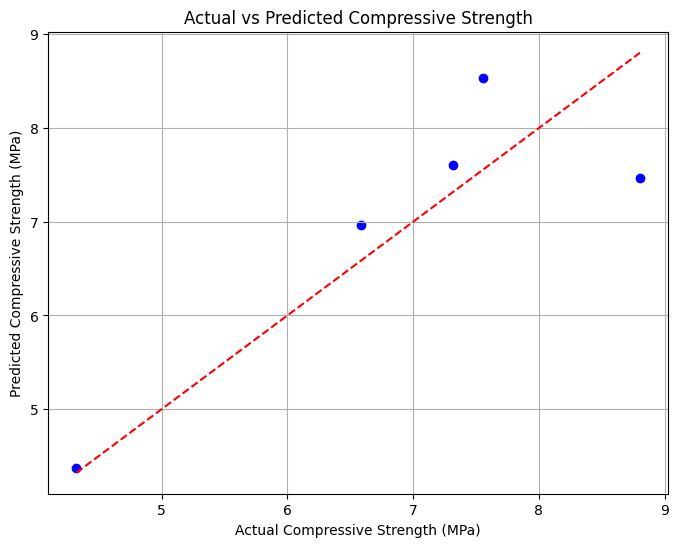

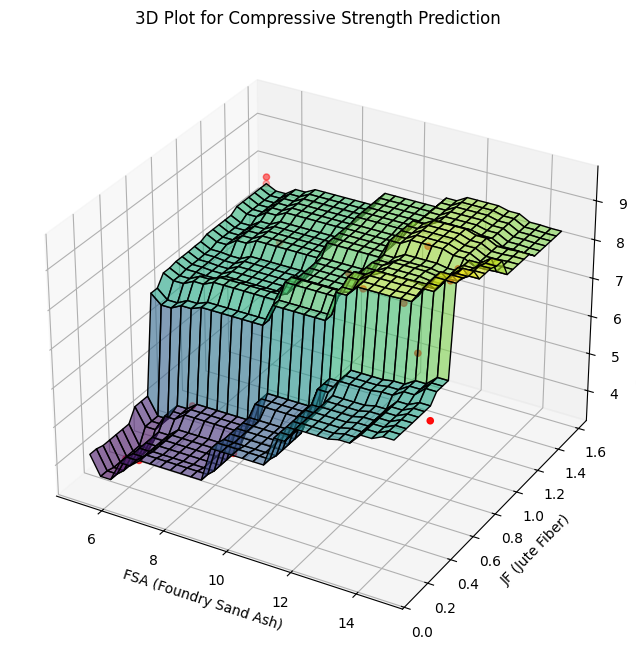

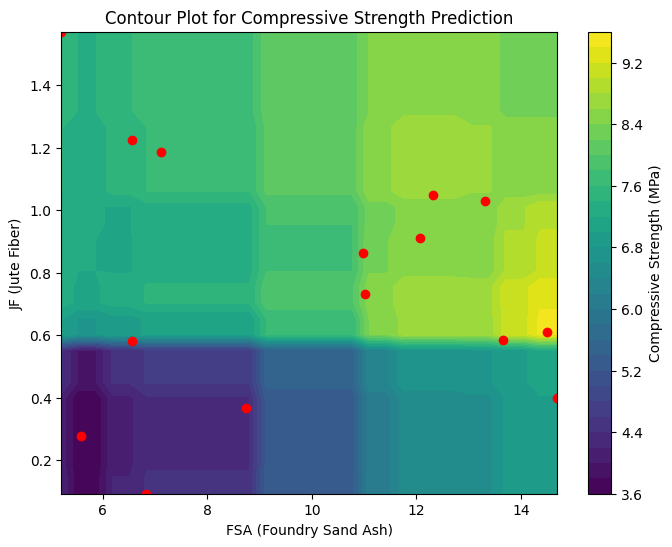

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_absolute_error

# Generate synthetic dataset with 15 samples
np.random.seed(42)

# Input variables: FSA (Foundry Sand Ash) and JF (Jute Fiber)
FSA = np.random.uniform(5, 15, 15)
JF = np.random.uniform(0, 2, 15)

# Target variable: Compressive Strength (MPa)
compressive_strength = 0.5 * FSA + 3 * JF + np.random.normal(0, 1, 15)

# Create DataFrame
data = pd.DataFrame({
    'FSA': FSA,
    'JF': JF,
    'Compressive Strength': compressive_strength
})

# Split into train/test sets
X = data[['FSA', 'JF']]
y = data['Compressive Strength']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train CatBoost model
model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=4, verbose=0)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.3f}")

# --- Plot 1: Actual vs Predicted ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Compressive Strength (MPa)')
plt.ylabel('Predicted Compressive Strength (MPa)')
plt.title('Actual vs Predicted Compressive Strength')
plt.grid(True)
plt.show()

# --- Plot 2: 3D Surface Plot ---
X_mesh, Y_mesh = np.meshgrid(np.linspace(FSA.min(), FSA.max(), 30), np.linspace(JF.min(), JF.max(), 30))
Z_mesh = model.predict(np.c_[X_mesh.ravel(), Y_mesh.ravel()]).reshape(X_mesh.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X_mesh, Y_mesh, Z_mesh, cmap='viridis', edgecolor='k', alpha=0.6)
ax.scatter(FSA, JF, compressive_strength, color='red')
ax.set_xlabel('FSA (Foundry Sand Ash)')
ax.set_ylabel('JF (Jute Fiber)')
ax.set_zlabel('Compressive Strength (MPa)')
ax.set_title('3D Plot for Compressive Strength Prediction')
plt.show()

# --- Plot 3: Contour Plot ---
plt.figure(figsize=(8, 6))
cp = plt.contourf(X_mesh, Y_mesh, Z_mesh, cmap='viridis', levels=30)
plt.colorbar(cp, label='Compressive Strength (MPa)')
plt.scatter(FSA, JF, color='red')
plt.xlabel('FSA (Foundry Sand Ash)')
plt.ylabel('JF (Jute Fiber)')
plt.title('Contour Plot for Compressive Strength Prediction')
plt.show()


Mean Absolute Error: 0.855


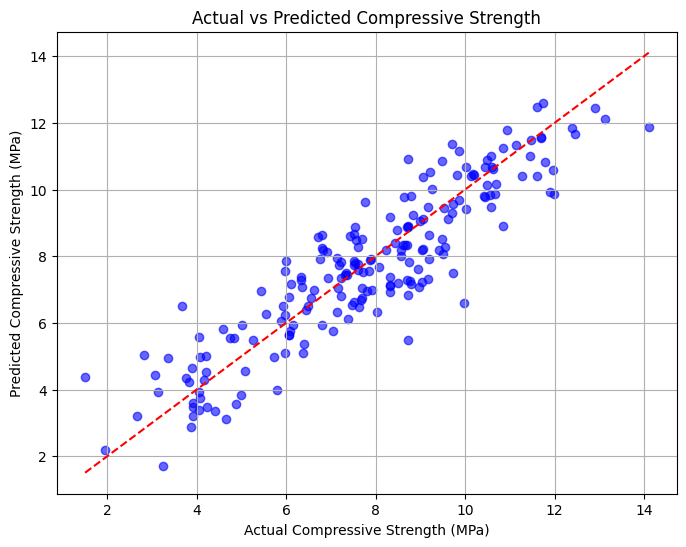

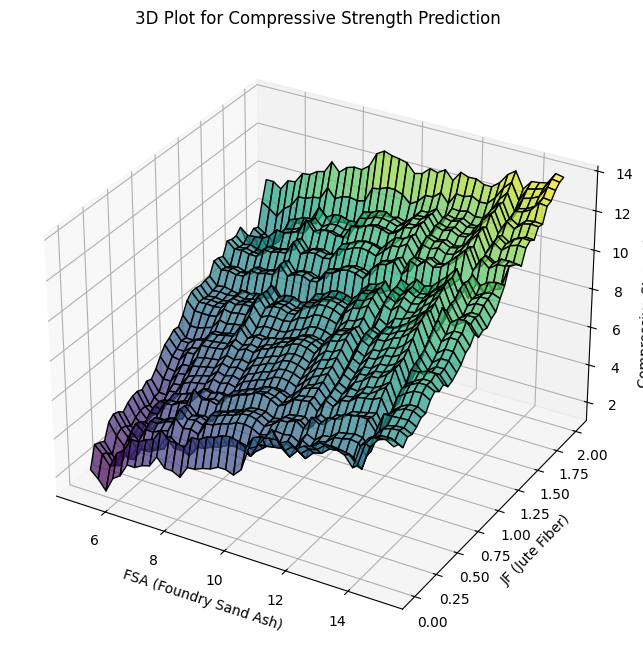

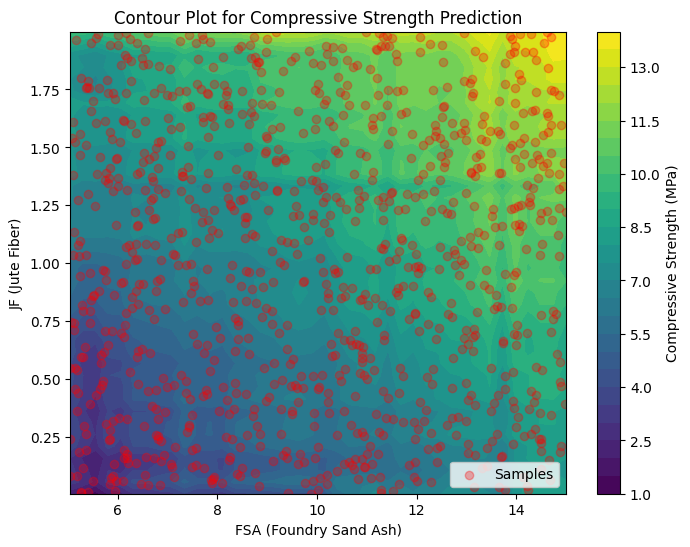

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_absolute_error

# Generate synthetic dataset with 1000 samples
np.random.seed(42)
n_samples = 1000

# Input variables
FSA = np.random.uniform(5, 15, n_samples)  # Foundry Sand Ash %
JF = np.random.uniform(0, 2, n_samples)    # Jute Fiber %

# Target variable: Compressive Strength (MPa)
# Hypothetical relationship + noise
compressive_strength = 0.5 * FSA + 3 * JF + np.random.normal(0, 1, n_samples)

# Create DataFrame
data = pd.DataFrame({
    'FSA': FSA,
    'JF': JF,
    'Compressive Strength': compressive_strength
})

# Split into train/test sets
X = data[['FSA', 'JF']]
y = data['Compressive Strength']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train CatBoost model
model = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=5, verbose=0)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.3f}")

# --- Plot 1: Actual vs Predicted ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Compressive Strength (MPa)')
plt.ylabel('Predicted Compressive Strength (MPa)')
plt.title('Actual vs Predicted Compressive Strength')
plt.grid(True)
plt.show()

# --- Plot 2: 3D Surface Plot ---
X_mesh, Y_mesh = np.meshgrid(np.linspace(FSA.min(), FSA.max(), 40),
                             np.linspace(JF.min(), JF.max(), 40))
Z_mesh = model.predict(np.c_[X_mesh.ravel(), Y_mesh.ravel()]).reshape(X_mesh.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X_mesh, Y_mesh, Z_mesh, cmap='viridis', edgecolor='k', alpha=0.7)
ax.set_xlabel('FSA (Foundry Sand Ash)')
ax.set_ylabel('JF (Jute Fiber)')
ax.set_zlabel('Compressive Strength (MPa)')
ax.set_title('3D Plot for Compressive Strength Prediction')
plt.show()

# --- Plot 3: Contour Plot ---
plt.figure(figsize=(8, 6))
cp = plt.contourf(X_mesh, Y_mesh, Z_mesh, cmap='viridis', levels=30)
plt.colorbar(cp, label='Compressive Strength (MPa)')
plt.scatter(FSA, JF, color='red', alpha=0.3, label='Samples')
plt.xlabel('FSA (Foundry Sand Ash)')
plt.ylabel('JF (Jute Fiber)')
plt.title('Contour Plot for Compressive Strength Prediction')
plt.legend()
plt.show()

Generating synthetic data...
Training CatBoost model...
0:	learn: 2.3729625	total: 13.5ms	remaining: 6.75s
100:	learn: 1.0005924	total: 1.83s	remaining: 7.25s
200:	learn: 0.9993222	total: 3.67s	remaining: 5.45s
300:	learn: 0.9982253	total: 4.73s	remaining: 3.13s
400:	learn: 0.9969976	total: 5.82s	remaining: 1.44s
499:	learn: 0.9958866	total: 6.88s	remaining: 0us

✅ Training completed in 7.04 seconds
📊 Mean Absolute Error (MAE): 0.805


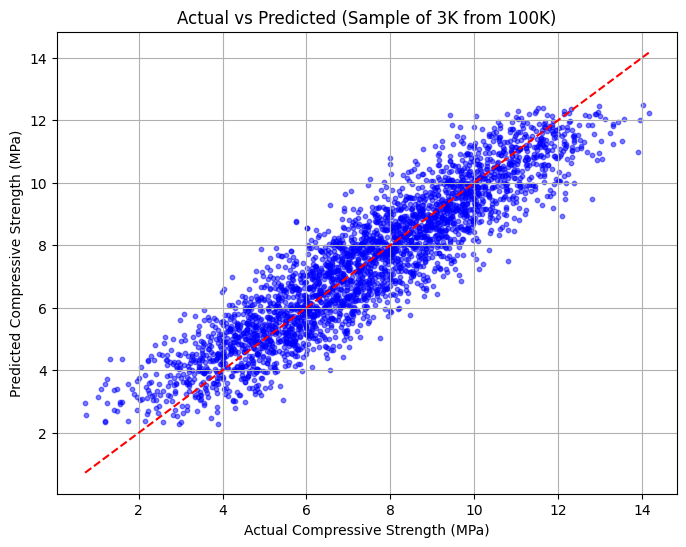

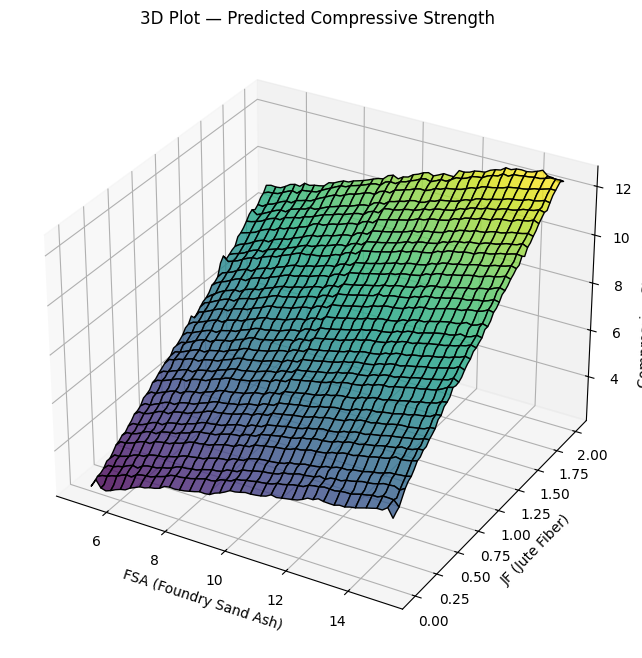

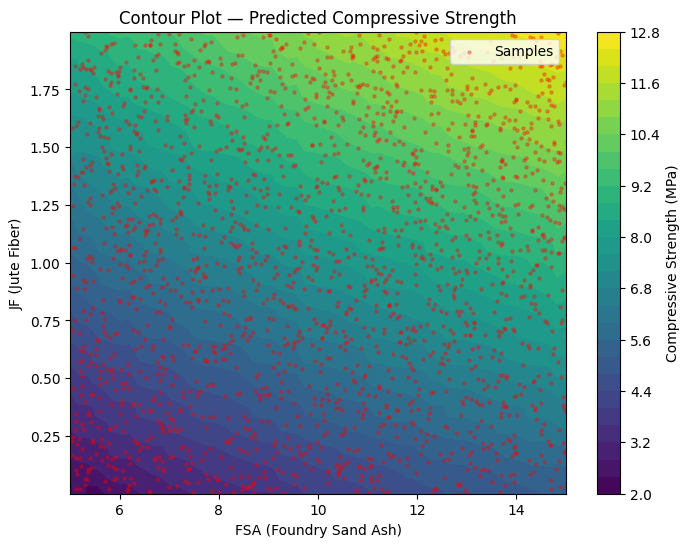

In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import time

# --- Generate synthetic dataset ---
np.random.seed(42)
n_samples = 100_000  # 100K samples

print("Generating synthetic data...")
FSA = np.random.uniform(5, 15, n_samples).astype(np.float32)  # Foundry Sand Ash (%)
JF = np.random.uniform(0, 2, n_samples).astype(np.float32)    # Jute Fiber (%)

# Simulated nonlinear relationship with noise
compressive_strength = (
    0.5 * FSA +
    3 * JF +
    0.05 * (FSA * JF) -        # interaction effect
    0.01 * FSA**2 +            # small quadratic term
    np.random.normal(0, 1, n_samples)
).astype(np.float32)

# Combine into DataFrame
data = pd.DataFrame({
    'FSA': FSA,
    'JF': JF,
    'Compressive Strength': compressive_strength
})

# --- Split data ---
X = data[['FSA', 'JF']]
y = data['Compressive Strength']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# --- Train CatBoost model ---
print("Training CatBoost model...")
start_time = time.time()

model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=100,
    task_type='CPU'  # change to 'GPU' if you have GPU support
)

model.fit(X_train, y_train)

elapsed = time.time() - start_time
print(f"\n✅ Training completed in {elapsed:.2f} seconds")

# --- Evaluate performance ---
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"📊 Mean Absolute Error (MAE): {mae:.3f}")

# --- Visualization (sample 3000 points for plotting) ---
sample_idx = np.random.choice(len(X_test), size=3000, replace=False)
X_vis = X_test.iloc[sample_idx]
y_vis = y_test.iloc[sample_idx]
y_pred_vis = model.predict(X_vis)

# Plot 1: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_vis, y_pred_vis, s=10, alpha=0.5, color='blue')
plt.plot([y_vis.min(), y_vis.max()], [y_vis.min(), y_vis.max()], 'r--')
plt.xlabel('Actual Compressive Strength (MPa)')
plt.ylabel('Predicted Compressive Strength (MPa)')
plt.title('Actual vs Predicted (Sample of 3K from 100K)')
plt.grid(True)
plt.show()

# --- 3D & Contour Plots ---
X_mesh, Y_mesh = np.meshgrid(np.linspace(FSA.min(), FSA.max(), 60),
                             np.linspace(JF.min(), JF.max(), 60))
Z_mesh = model.predict(np.c_[X_mesh.ravel(), Y_mesh.ravel()]).reshape(X_mesh.shape)

# Plot 2: 3D Surface Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X_mesh, Y_mesh, Z_mesh, cmap='viridis', edgecolor='k', alpha=0.8)
ax.set_xlabel('FSA (Foundry Sand Ash)')
ax.set_ylabel('JF (Jute Fiber)')
ax.set_zlabel('Compressive Strength (MPa)')
ax.set_title('3D Plot — Predicted Compressive Strength')
plt.show()

# Plot 3: Contour Plot
plt.figure(figsize=(8, 6))
cp = plt.contourf(X_mesh, Y_mesh, Z_mesh, cmap='viridis', levels=30)
plt.colorbar(cp, label='Compressive Strength (MPa)')
plt.scatter(FSA[:2000], JF[:2000], color='red', s=5, alpha=0.3, label='Samples')
plt.xlabel('FSA (Foundry Sand Ash)')
plt.ylabel('JF (Jute Fiber)')
plt.title('Contour Plot — Predicted Compressive Strength')
plt.legend()
plt.show()


In [ ]:
print("The prediction model used is CatBoostRegressor.")